In [2]:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import numpy as np

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

import seaborn as sns

from matplotlib_venn import venn3

import statsmodels.api as sm

import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import descri_function as des_fun

In [2]:
# Read data with model outputs
df = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/LR_MV_xgb_mlp_sintetic_08_05_2026.parquet')

df_meta = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/sintetic_outbreak_metadata_20260325.parquet')

In [3]:
df.co_ibge.nunique()

5365

In [4]:
df.year_week.min()

'2022-42'

In [5]:
data = df[df.year_week >= '2024-51']

# Create the columns indicating the onset and periods for the sintetic outbreak inserted

In [6]:
# convert to weekly period (ISO-like)
df = df.assign(yw = pd.to_datetime(df['year_week'] + '-1', format='%Y-%W-%w').dt.to_period('W'))
df_meta = df_meta.assign(start_yw = pd.to_datetime(df_meta['start_year_week'] + '-1', format='%Y-%W-%w').dt.to_period('W'))
df_meta = df_meta.assign(end_yw   = pd.to_datetime(df_meta['end_year_week'] + '-1', format='%Y-%W-%w').dt.to_period('W'))

In [7]:
def compute_replicates(df, df_meta):
    df = df.copy()

    for code, set_muni in df.groupby('co_ibge'):
        meta_city = df_meta[df_meta['co_ibge'] == code]

        warning = set_muni['warning_final_mem_surge_01'].values
        yw = set_muni['yw'].values

        for rep, dta in meta_city.groupby('replicate'):

            # --- STEP 1: identify NON-coincident starts ---
            is_start = set_muni['yw'].isin(dta['start_yw']).values
            noncoincident_start = is_start & (warning == 0)

            # store start signal
            df.loc[set_muni.index, f'replicate_{rep}_surge'] = noncoincident_start.astype(int)

            # --- STEP 2: keep only intervals whose start is non-coincident ---
            valid_intervals = dta[dta['start_yw'].isin(set_muni.loc[noncoincident_start, 'yw'])]

            if len(valid_intervals) == 0:
                df.loc[set_muni.index, f'replicate_{rep}_surge_consec'] = 0
                continue

            # build consecutive mask WITHOUT warning condition
            cond_consec = (
                (yw[:, None] >= valid_intervals['start_yw'].values) &
                (yw[:, None] <= valid_intervals['end_yw'].values)
            ).any(axis=1)

            df.loc[set_muni.index, f'replicate_{rep}_surge_consec'] = cond_consec.astype(int)

    return df

In [8]:
result = compute_replicates(df, df_meta)

In [9]:
data = result[result.year_week >= '2024-51']

# Count the average number of anomalies issued by models

In [10]:
# =============================================================================
# COUNT NUMBER OF ANOMALIES PER MODEL AND REPLICATE
# =============================================================================

results = []

for rep in range(32):

    lst_eadms = [
        f'C2_alarms_{rep}',
        f'sinal_evi_replicate_{rep}',
        f'EWS_ISF_replicate_{rep}',
        f'EWS_LOF_replicate_{rep}',
        f'EWS_OCSVM_replicate_{rep}',
        f'EWS_COPOD_replicate_{rep}',
        f'EWS_Rt_replicate_{rep}'
    ]

    # Keep only columns that actually exist
    lst_eadms = [
        col for col in lst_eadms
        if col in data.columns
    ]

    # Sum anomalies
    counts = data[lst_eadms].sum()

    # Convert to dataframe
    df_rep = counts.reset_index()

    df_rep.columns = ['model', 'n_anomalies']

    # Add replicate ID
    df_rep['replicate'] = rep

    results.append(df_rep)

# Final table
eadms_counts = pd.concat(results, ignore_index=True)

In [11]:
ears = data.filter(regex=r'^C2_alarms_')
evi = data.filter(regex=r'^sinal_evi_replicate')
isf = data.filter(regex=r'^EWS_ISF_replicate')
lof = data.filter(regex=r'^EWS_LOF_replicate')
ocsvm = data.filter(regex=r'^EWS_OCSVM_replicate')
copod = data.filter(regex=r'EWS_COPOD_replicate')
ngm = data.filter(regex=r'EWS_Rt_replicate')
mv = data.filter(regex=r'hard_voting_ivas_rep')
lr = data.filter(regex=r'sinal_ens_ivas_rep')
xgb = data.filter(regex=r'signal_ensemble_xgb50_rep')
mlp = data.filter(regex=r'signal_ensemble_mlp50')

for df in [ears, evi, isf, ocsvm,copod,ngm,mv,lr,xgb,mlp]:

    print('Mean warning sintetic surges with 95% CI',des_fun.mean_confidence_interval(
       df.sum(), confidence=0.95
    ))

Mean warning sintetic surges with 95% CI (32676, 32593, 32758)
Mean warning sintetic surges with 95% CI (36751, 36691, 36811)
Mean warning sintetic surges with 95% CI (26631, 26494, 26769)
Mean warning sintetic surges with 95% CI (28176, 28020, 28332)
Mean warning sintetic surges with 95% CI (27452, 27216, 27689)
Mean warning sintetic surges with 95% CI (32738, 32601, 32875)
Mean warning sintetic surges with 95% CI (29944, 29778, 30111)
Mean warning sintetic surges with 95% CI (54147, 53859, 54436)
Mean warning sintetic surges with 95% CI (50847, 50512, 51183)
Mean warning sintetic surges with 95% CI (53047, 52302, 53791)


In [12]:
# =============================================================================
# MODEL COLLECTION
# =============================================================================

models = {
    'EARS': data.filter(regex=r'^C2_alarms_'),
    'EVI': data.filter(regex=r'^sinal_evi_replicate'),
    'ISF': data.filter(regex=r'^EWS_ISF_replicate'),
    'LOF': data.filter(regex=r'^EWS_LOF_replicate'),
    'OCSVM': data.filter(regex=r'^EWS_OCSVM_replicate'),
    'COPOD': data.filter(regex=r'^EWS_COPOD_replicate'),
    'NGM': data.filter(regex=r'^EWS_Rt_replicate'),
    'MV': data.filter(regex=r'^hard_voting_ivas_rep'),
    'LR': data.filter(regex=r'^sinal_ens_ivas_rep'),
    'XGB': data.filter(regex=r'^signal_ensemble_xgb50_rep'),
    'MLP': data.filter(regex=r'^signal_ensemble_mlp50')
}

# =============================================================================
# SUMMARY TABLE
# =============================================================================

results = []

for model_name, df_model in models.items():

    # Number of warnings per replicate
    warnings_per_rep = df_model.sum()

    # Mean + CI
    mean_, lower_, upper_ = des_fun.mean_confidence_interval(
        warnings_per_rep,
        confidence=0.95
    )

    results.append({
        'model': model_name,
        'mean_warnings': mean_,
        'ci_lower': lower_,
        'ci_upper': upper_,
        'std': warnings_per_rep.std(),
        'min': warnings_per_rep.min(),
        'max': warnings_per_rep.max()
    })

# Final dataframe
summary_warnings = pd.DataFrame(results)

# Sort by mean warnings
summary_warnings = summary_warnings.sort_values(
    'mean_warnings',
    ascending=False
)

summary_warnings

,model,mean_warnings,ci_lower,ci_upper,std,min,max
8,LR,54147,53859,54436,800.277749,50913,54840
10,MLP,53047,52302,53791,2064.868200,48175,57719
9,XGB,50847,50512,51183,930.421581,45964,51565
1,EVI,36751,36691,36811,166.886113,35998,36987
6,NGM,32738,32601,32875,378.696576,31017,33158
0,EARS,32676,32593,32758,229.515178,32092,33587
7,MV,29944,29778,30111,462.169808,27746,30280
3,LOF,28412,28154,28670,715.270823,24744,28947
4,OCSVM,28176,28020,28332,433.529782,26165,28599
5,COPOD,27452,27216,27689,656.197797,24278,27914


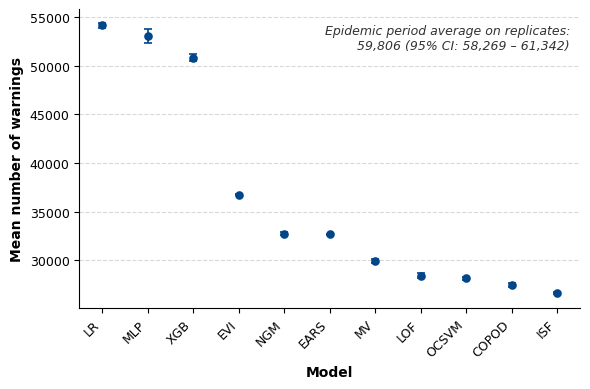

In [13]:
import matplotlib.pyplot as plt

# --- 1. Lancet Style Configuration ---

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# Color choice: A deep, professional blue
LANCET_NAVY = '#00468B'

fig, ax = plt.subplots(figsize=(6, 4))

# --- 2. Plotting ---
# Use a smaller 'o' and thinner error bar lines for a refined look
ax.errorbar(
    summary_warnings['model'],
    summary_warnings['mean_warnings'],
    yerr=[
        summary_warnings['mean_warnings'] - summary_warnings['ci_lower'],
        summary_warnings['ci_upper'] - summary_warnings['mean_warnings']
    ],
    fmt='o',
    color=LANCET_NAVY,
    markersize=5,
    capsize=3,          # Smaller caps are more elegant
    elinewidth=1.2,     # Thickness of the CI line
    markeredgewidth=1.2 # Thickness of the circle border
)

# Place text in the upper right corner
stats_text = (
    "Epidemic period average on replicates:\n"
    "59,806 (95% CI: 58,269 – 61,342)"
)

ax.text(
    0.98, 0.95, stats_text,
    transform=ax.transAxes,
    fontsize=9,
    ha='right', # Right aligned
    va='top',
    fontstyle='italic',
    color='#333333'
)

# --- 3. Axes Aesthetics ---
ax.set_ylabel('Mean number of warnings', fontsize=10, fontweight='bold')
ax.set_xlabel('Model', fontsize=10, fontweight='bold')

# Lancet style: No top or right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add a subtle horizontal grid to help guide the eye across models
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray')
ax.set_axisbelow(True)

# Adjust ticks
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

# Clean up spacing
plt.tight_layout()

# --- 4. Export (as discussed previously) ---
plt.savefig('/home/juliane.oliveira/workspace/aesop-detection-models/figures/mean_anomaly_sintetic.pdf', format='pdf', bbox_inches='tight')

plt.show()

# Read data

In [6]:
from pathlib import Path

out_dir = Path(
    "/home/juliane.oliveira/workspace/Data/timing_metrics"
)

perf_files = sorted(out_dir.glob("metrics_rep_*.parquet"))

timing_files = sorted(out_dir.glob("timing_rep_*.parquet"))



final_perf = pd.concat(
    [pd.read_parquet(f) for f in perf_files],
    ignore_index=True
)

final_timing = pd.concat(
    [pd.read_parquet(f) for f in timing_files],
    ignore_index=True
)

In [7]:
final_perf.Metric.unique()

array(['Sensitivity ', 'Specificity', 'PPV', 'NPV'], dtype=object)

# Create 95% CI for the values being analysed

In [8]:
final_timing = final_timing.assign(n3_per = final_timing.n3*100/final_timing.total_aih_warning,
                                   n2_per = final_timing.n2*100/final_timing.total_aih_warning,
                                   n1_per = final_timing.n1*100/final_timing.total_aih_warning,
                                   n0_per = final_timing.n0*100/final_timing.total_aih_warning,
                                   missed_per = final_timing.missed*100/final_timing.total_aih_warning,)

In [9]:
def add_ci(df, col_num, col_model):

    mean_list = []
    lower_list = []
    upper_list = []

    for model in df[col_model]:

        dta = df[df[col_model] == model]

        m, l, u = des_fun.mean_confidence_interval2(
            dta[col_num]
        )

        mean_list.append(m)
        lower_list.append(l)
        upper_list.append(u)

    df[f"{col_num.replace('_per', '')}_CI_mean"] = mean_list
    df[f"{col_num.replace('_per', '')}_CI_low"] = lower_list
    df[f"{col_num.replace('_per', '')}_CI_high"] = upper_list

    return df

In [10]:
final_timing.columns

Index(['model', 'n3', 'n2', 'n1', 'n0', 'missed', 'total_aih_warning', 'rep',
       'n3_per', 'n2_per', 'n1_per', 'n0_per', 'missed_per'],
      dtype='object')

In [11]:
cols_to_ci = ['n3_per', 'n2_per', 'n1_per', 'n0_per', 'missed_per']

for col in cols_to_ci:
    add_ci(final_timing, col, 'model' )

In [12]:
final_timing.columns

Index(['model', 'n3', 'n2', 'n1', 'n0', 'missed', 'total_aih_warning', 'rep',
       'n3_per', 'n2_per', 'n1_per', 'n0_per', 'missed_per', 'n3_CI_mean',
       'n3_CI_low', 'n3_CI_high', 'n2_CI_mean', 'n2_CI_low', 'n2_CI_high',
       'n1_CI_mean', 'n1_CI_low', 'n1_CI_high', 'n0_CI_mean', 'n0_CI_low',
       'n0_CI_high', 'missed_CI_mean', 'missed_CI_low', 'missed_CI_high'],
      dtype='object')

# Plot results of anticipation and performance for the sintetic data

In [13]:
# Custom order for regions/population groups
order = ['COPOD', 'EARS', 'EVI', 'MV', 'ISF', 'LOF', 'FFA','LR', 'MLP',
       'NGM', 'OCSVM', 'XGBOOST']
df_plot = final_timing.groupby('model')[['n3_CI_mean',
       'n3_CI_low', 'n3_CI_high', 'n2_CI_mean', 'n2_CI_low', 'n2_CI_high',
       'n1_CI_mean', 'n1_CI_low', 'n1_CI_high', 'n0_CI_mean', 'n0_CI_low',
       'n0_CI_high', 'missed_CI_mean', 'missed_CI_low', 'missed_CI_high']].max().reset_index()
# Ensure the 'Region_or_PopSize' column is treated as categorical for correct ordering
df_plot["Model"] = pd.Categorical(df_plot["model"], categories=order, ordered=True)
# Sort in descending order so the plot reads from National (top) to Large (bottom)
df_plot = df_plot.sort_values("Model", ascending=False).reset_index(drop=True)

df_plot = df_plot[['Model', 'n3_CI_mean',
       'n3_CI_low', 'n3_CI_high', 'n2_CI_mean', 'n2_CI_low', 'n2_CI_high',
       'n1_CI_mean', 'n1_CI_low', 'n1_CI_high', 'n0_CI_mean', 'n0_CI_low',
       'n0_CI_high', 'missed_CI_mean', 'missed_CI_low', 'missed_CI_high']]

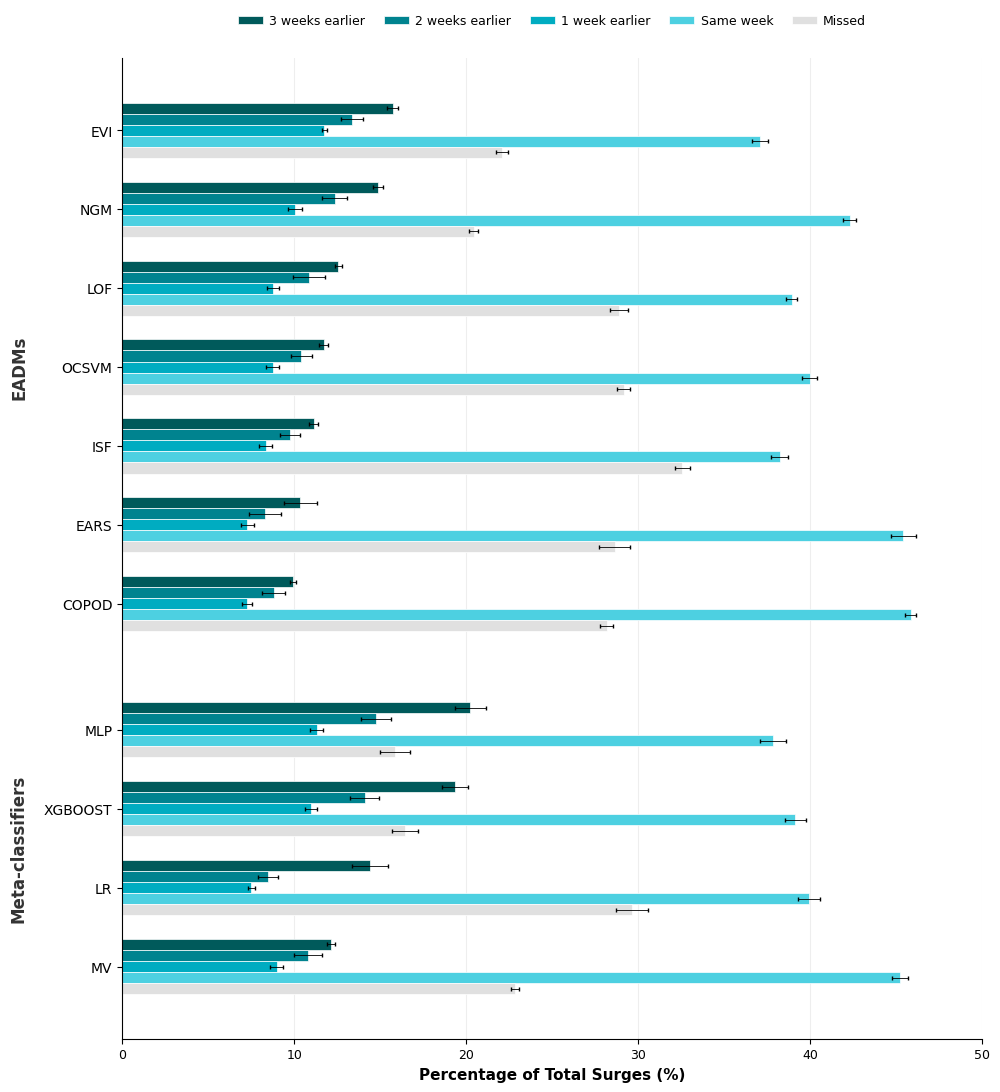

In [14]:
# 2. Agrupamento
ml_ensemble_group = ['XGBOOST', 'LR', 'MV', 'MLP']
df_plot['Group'] = df_plot['Model'].apply(lambda x: 'Meta-classifiers' if x in ml_ensemble_group else 'EADMs')

# Ordenar por grupo para ficarem juntos no gráfico
df_plot = df_plot.sort_values(by=['Group', 'n3_CI_mean'], ascending=[True, False]).reset_index(drop=True)

# 3. Configurações de Estilo
plt.rcParams.update({
    'font.family': 'sans-serif',
    # Matplotlib will try these in order. 
    # Liberation Sans looks identical to Arial and is standard on Linux.
    'font.sans-serif': ['Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})


# DISTINCT PALETTE FOR SYNTHETIC DATA: Deep Teal to Neutral Gray
colors = ['#005a5b', '#00838f', '#00acc1', '#4dd0e1', '#e0e0e0']
metrics = ['n3', 'n2', 'n1', 'n0', 'missed']
labels = ['3 weeks earlier', '2 weeks earlier', '1 week earlier', 'Same week', 'Missed']

fig, ax = plt.subplots(figsize=(10, 11))

bar_height = 0.14
# Criar índices com um "gap" entre os grupos
indices = []
current_pos = 0
for i in range(len(df_plot)):
    if i > 0 and df_plot.iloc[i]['Group'] != df_plot.iloc[i-1]['Group']:
        current_pos += 0.6  # Espaço extra entre blocos
    indices.append(current_pos)
    current_pos += 1

indices = np.array(indices)

# 4. Plotagem
for i, (metric, label) in enumerate(zip(metrics, labels)):
    per = df_plot[f'{metric}_CI_mean']
    errors = [per - df_plot[f'{metric}_CI_low'], df_plot[f'{metric}_CI_high'] - per]
    
    pos = indices + (i * bar_height)
    
    ax.barh(pos, per, bar_height, label=label, color=colors[i], edgecolor='white', linewidth=0.5)
    ax.errorbar(per, pos, xerr=errors, fmt='none', ecolor='black', capsize=1.5, elinewidth=0.6)

# 5. Estética Final
# Centralizar labels dos modelos no meio do bloco de barras
ax.set_yticks(indices + (bar_height * (len(metrics)-1) / 2))
ax.set_yticklabels(df_plot['Model'], fontsize=10)
ax.invert_yaxis()

ax.set_xlabel('Percentage of Total Surges (%)', fontsize=11, fontweight='bold')

# X-axis cleanup
ax.set_xlim(0, 50) 
ax.xaxis.set_tick_params(labelsize=9)

# Adicionar labels dos Grupos
for group in df_plot['Group'].unique():
    group_indices = indices[df_plot['Group'] == group]
    avg_pos = group_indices.mean() + (bar_height * 2)
    ax.text(-6, avg_pos, group, fontweight='bold', fontsize=12, rotation=90, va='center', ha='center', color='#333333')

# Clean Lancet grid lines and borders
ax.xaxis.grid(True, linestyle='-', color='#eeeeee', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# --- 5. The Lancet Legend (One row, top) ---
ax.legend(
    loc='lower center', 
    bbox_to_anchor=(0.5, 1.02), 
    ncol=5, 
    frameon=False, 
    fontsize=9, 
    handletextpad=0.5,
    columnspacing=1.5
)

plt.tight_layout()
plt.show()

In [15]:
df_plot[df_plot.Model.isin(['EVI',
 'NGM',
 'LOF',
 'OCSVM',
 'ISF',
 'EARS',
 'COPOD'])][['Model','missed_CI_mean','missed_CI_low', 'missed_CI_high']].sort_values(by=['missed_CI_mean'], ascending=[True])


,Model,missed_CI_mean,missed_CI_low,missed_CI_high
1,NGM,20.4253,20.1916,20.6589
0,EVI,22.0860,21.7530,22.4190
6,COPOD,28.1651,27.7748,28.5553
5,EARS,28.6384,27.7443,29.5326
2,LOF,28.8964,28.3792,29.4135
3,OCSVM,29.1613,28.7934,29.5292
4,ISF,32.5623,32.1392,32.9854


In [16]:
df_plot.to_parquet('df_plot_sintetic_timing.parquet')

# Metrics analysis

In [17]:
def add_ci(df, col_num, col_model):

    mean_list = []
    lower_list = []
    upper_list = []

    for model in df[col_model]:

        dta = df[df[col_model] == model]

        m, l, u = des_fun.mean_confidence_interval2(
            dta[col_num]
        )

        mean_list.append(m)
        lower_list.append(l)
        upper_list.append(u)

    df[f"{col_num.replace('_per', '')}_CI_mean"] = mean_list
    df[f"{col_num.replace('_per', '')}_CI_low"] = lower_list
    df[f"{col_num.replace('_per', '')}_CI_high"] = upper_list

    return df

In [18]:
table = pd.pivot_table(
    final_perf, values="Value", index=["model", "rep"], columns=["Metric"], aggfunc="max"
).reset_index()

In [19]:
table.columns

Index(['model', 'rep', 'NPV', 'PPV', 'Sensitivity ', 'Specificity'], dtype='object', name='Metric')

In [20]:
cols_to_ci = [ 'NPV', 'PPV', 'Sensitivity ', 'Specificity']

for col in cols_to_ci:
    add_ci(table, col, 'model' )

In [21]:
table

Metric,model,rep,NPV,PPV,Sensitivity,Specificity,NPV_CI_mean,NPV_CI_low,NPV_CI_high,PPV_CI_mean,PPV_CI_low,PPV_CI_high,Sensitivity _CI_mean,Sensitivity _CI_low,Sensitivity _CI_high,Specificity_CI_mean,Specificity_CI_low,Specificity_CI_high
0,COPOD,0,0.989,0.838,0.766,0.906,0.9767,0.9757,0.9778,0.8668,0.8605,0.8732,0.7184,0.7145,0.7224,0.8868,0.8854,0.8881
1,COPOD,1,0.986,0.776,0.705,0.881,0.9767,0.9757,0.9778,0.8668,0.8605,0.8732,0.7184,0.7145,0.7224,0.8868,0.8854,0.8881
2,COPOD,2,0.974,0.872,0.697,0.885,0.9767,0.9757,0.9778,0.8668,0.8605,0.8732,0.7184,0.7145,0.7224,0.8868,0.8854,0.8881
3,COPOD,3,0.975,0.877,0.723,0.887,0.9767,0.9757,0.9778,0.8668,0.8605,0.8732,0.7184,0.7145,0.7224,0.8868,0.8854,0.8881
4,COPOD,4,0.975,0.871,0.702,0.886,0.9767,0.9757,0.9778,0.8668,0.8605,0.8732,0.7184,0.7145,0.7224,0.8868,0.8854,0.8881
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,XGBOOST,27,0.984,0.786,0.838,0.785,0.9844,0.9835,0.9854,0.7814,0.7721,0.7907,0.8358,0.8280,0.8435,0.7858,0.7826,0.7891
348,XGBOOST,28,0.984,0.789,0.832,0.786,0.9844,0.9835,0.9854,0.7814,0.7721,0.7907,0.8358,0.8280,0.8435,0.7858,0.7826,0.7891
349,XGBOOST,29,0.984,0.784,0.829,0.784,0.9844,0.9835,0.9854,0.7814,0.7721,0.7907,0.8358,0.8280,0.8435,0.7858,0.7826,0.7891
350,XGBOOST,30,0.983,0.793,0.831,0.788,0.9844,0.9835,0.9854,0.7814,0.7721,0.7907,0.8358,0.8280,0.8435,0.7858,0.7826,0.7891


In [22]:
res = table.groupby('model')[['NPV_CI_mean', 'NPV_CI_low', 'NPV_CI_high', 'PPV_CI_mean', 'PPV_CI_low',
       'PPV_CI_high', 'Sensitivity _CI_mean', 'Sensitivity _CI_low',
       'Sensitivity _CI_high', 'Specificity_CI_mean', 'Specificity_CI_low',
       'Specificity_CI_high']].max().reset_index()

In [23]:
res

Metric,model,NPV_CI_mean,NPV_CI_low,NPV_CI_high,PPV_CI_mean,PPV_CI_low,PPV_CI_high,Sensitivity _CI_mean,Sensitivity _CI_low,Sensitivity _CI_high,Specificity_CI_mean,Specificity_CI_low,Specificity_CI_high
0,COPOD,0.9767,0.9757,0.9778,0.8668,0.8605,0.8732,0.7184,0.7145,0.7224,0.8868,0.8854,0.8881
1,EARS,0.9766,0.9753,0.9779,0.8788,0.8707,0.8869,0.7137,0.7047,0.7226,0.8988,0.8972,0.9005
2,EVI,0.9806,0.9796,0.9815,0.8238,0.8144,0.8333,0.7791,0.7757,0.7824,0.8397,0.8385,0.8408
3,ISF,0.9732,0.9722,0.9742,0.8618,0.8547,0.8689,0.6743,0.6701,0.6786,0.8834,0.8828,0.8840
4,LOF,0.9758,0.9746,0.9769,0.8509,0.8437,0.8582,0.7111,0.7059,0.7162,0.8711,0.8703,0.8719
5,LR,0.9727,0.9711,0.9742,0.7819,0.7730,0.7908,0.7036,0.6943,0.7128,0.7945,0.7907,0.7983
6,MLP,0.9848,0.9837,0.9858,0.7740,0.7634,0.7846,0.8414,0.8330,0.8498,0.7758,0.7707,0.7810
7,MV,0.9808,0.9800,0.9816,0.8542,0.8468,0.8616,0.7715,0.7692,0.7738,0.8722,0.8714,0.8729
8,NGM,0.9824,0.9817,0.9831,0.8378,0.8294,0.8463,0.7958,0.7935,0.7981,0.8541,0.8535,0.8547
9,OCSVM,0.9757,0.9748,0.9766,0.8562,0.8488,0.8635,0.7084,0.7047,0.7121,0.8766,0.8759,0.8772


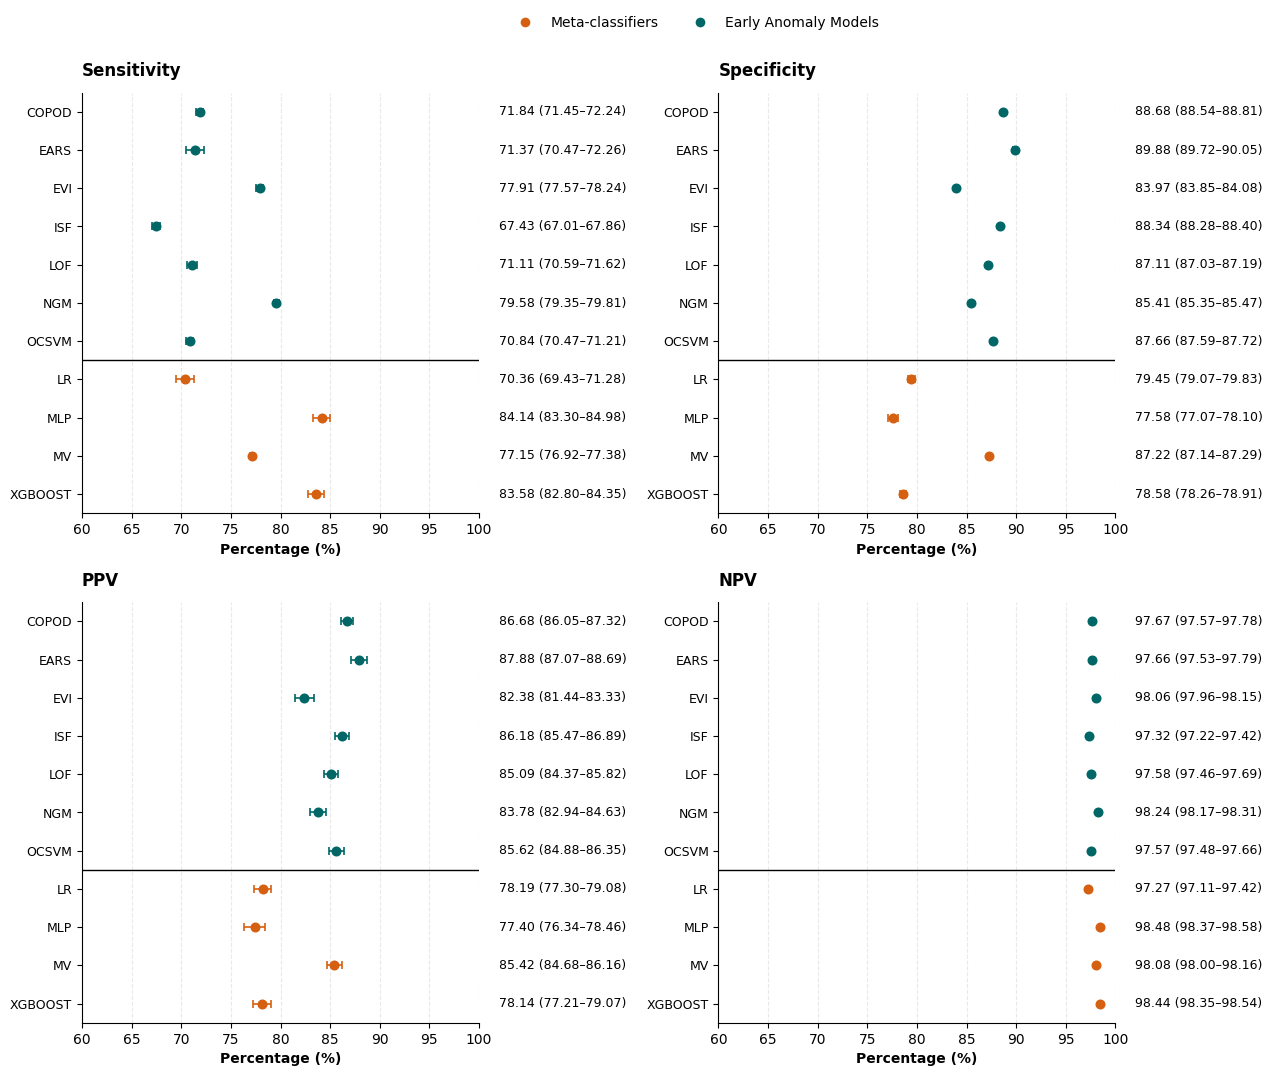

In [24]:
df_plot = res.copy()

# --- 1. Data Setup & Grouping (Simulated based on your columns) ---
ml_ensemble_group = ['XGBOOST', 'LR', 'MV', 'MLP']
df_plot['Group'] = df_plot['model'].apply(lambda x: 'Meta-classifiers' if x in ml_ensemble_group else 'EADMs')

# Sort to match the image structure (EADMs on top, Meta-classifiers on bottom)
# Note: The image shows EADMs first, then a line, then Meta-classifiers.
df_plot = df_plot.sort_values(by=['Group', 'model'], ascending=[True, True]).reset_index(drop=True)

# --- 2. Lancet Style Configuration ---
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'Liberation Sans', 'DejaVu Sans'],
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'axes.linewidth': 0.8
})

# SYNTHETIC DATA PALETTE (Matching the logic of your previous plot)
# EADMs = Muted Dark Teal, Meta-classifiers = Ochre/Warm Orange-Brown
COLOR_EADM = '#006666'
COLOR_META = '#D66011'

# Metrics configuration mapping to your DataFrame columns
# Format: (Panel Title, Mean Col, Low Col, High Col)
panels = [
    ('Sensitivity', 'Sensitivity _CI_mean', 'Sensitivity _CI_low', 'Sensitivity _CI_high'), # Swap with Sensitivity columns if available!
    ('Specificity', 'Specificity_CI_mean', 'Specificity_CI_low', 'Specificity_CI_high'),
    ('PPV', 'PPV_CI_mean', 'PPV_CI_low', 'PPV_CI_high'),
    ('NPV', 'NPV_CI_mean', 'NPV_CI_low', 'NPV_CI_high')
]

# Set up the 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=False, sharey=False)
axes = axes.flatten()

# --- 3. Base Positions & Group Boundary Line ---
y_positions = np.arange(len(df_plot))

# Find where the group changes to draw the horizontal separator line
split_idx = np.where(df_plot['Group'] != df_plot['Group'].shift(-1))[0][0]
line_y = (y_positions[split_idx] + y_positions[split_idx + 1]) / 2

# --- 4. Plotting Loop ---
for p_idx, (title, mean_col, low_col, high_col) in enumerate(panels):
    ax = axes[p_idx]
    
    # Plot each model point individually to assign the correct group color
    for idx, row in df_plot.iterrows():
        color = COLOR_META if row['Group'] == 'Meta-classifiers' else COLOR_EADM
        mean_val = row[mean_col]
        
        # Scale to percentage if your data is between 0 and 1
        if mean_val <= 1.0:
            mean_val *= 100
            err_low = row[low_col] * 100
            err_high = row[high_col] * 100
        else:
            err_low = row[low_col]
            err_high = row[high_col]
            
        x_err = [[mean_val - err_low], [err_high - mean_val]]
        
        # Plot point and error bar
        ax.errorbar(
            mean_val, idx, xerr=x_err, fmt='o', color=color,
            markersize=6, capsize=3, elinewidth=1.2, markeredgewidth=1.2
        )
        
        # Add the string representation text on the right side of the panel
        text_str = f"{mean_val:.2f} ({err_low:.2f}–{err_high:.2f})"
        ax.text(102, idx, text_str, va='center', ha='left', fontsize=9, fontfamily='sans-serif')

    # Panel Title & Aesthetics
    ax.set_title(title, loc='left', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Percentage (%)', fontsize=10, fontweight='bold')
    
    # Y-Ticks setup
    ax.set_yticks(y_positions)
    ax.set_yticklabels(df_plot['model'], fontsize=9)
    ax.invert_yaxis()  # Keeps top models at the top
    
    # Solid horizontal group separator line
    ax.axhline(y=line_y, color='black', linewidth=1.0)
    
    # Background Grid and Limits
    ax.set_xlim(60, 100) # Match the scale from your image
    ax.xaxis.grid(True, linestyle='--', color='#e0e0e0', alpha=0.7)
    ax.set_axisbelow(True)
    
    # Hide top and right spines
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

# --- 5. Global Unified Legend ---
# Create custom handles for the legend to place at the top center


legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_META, markersize=8, label='Meta-classifiers'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_EADM, markersize=8, label='Early Anomaly Models')
]

fig.legend(
    handles=legend_elements, 
    loc='upper center', 
    bbox_to_anchor=(0.5, 0.98), 
    ncol=2, 
    frameon=False, 
    fontsize=10
)

# Adjust layouts to accommodate the text on the right
plt.tight_layout(rect=[0, 0, 0.92, 0.94]) 
plt.show()

In [26]:
df_plot.to_parquet('df_plot_metrics_sint.parquet')

# Analyse the results according to intensity

## Create columns with intensity and wanings

In [76]:
# Classify MEM surges accordingly to intensity
df_mem = pd.read_parquet('/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/mem_output_26_03_2026.parquet')

df_mem = df_mem[df_mem.epiyear.isin([2022,2023, 2024,2025])]

dta_intens = df_mem.groupby(['co_ibge'])[['baseline', 'post_baseline', 'epidemic_threshold',
       'post_threshold', 'low_level', 'medium_level', 'high_level']].max().reset_index()

In [77]:
# =============================================================================
# FUNCTION TO ASSIGN INTENSITY
# =============================================================================

def classify_block(values, base, epi, low, med, high):

    # Check from most severe to least

    if (values > high).any():
        return 'very high'

    elif (values > med).any():
        return 'high'

    elif (values > low).any():
        return 'medium'

    elif (values > epi).any():
        return 'low'

    elif ((values > base) & (values <= epi)).any():
        return 'very low'

    elif (values <= base).all():
        return 'baseline'

    return np.nan


# =============================================================================
# CREATE INTENSITY LABELS
# =============================================================================

def ints_creator(df, dta_intens):

    lst = []

    # Automatically detect replicate columns
    rep_cols = [
        c for c in df.columns
        if c.startswith('replicate_') and c.endswith('_surge_consec')
    ]

    for code, set_muni in df.groupby('co_ibge'):

        print(f'Processing municipality: {code}')

        set_muni = (
            set_muni
            .copy()
            .sort_values('year_week')
        )

        # Municipality-specific thresholds
        set_muni_inten = dta_intens[
            dta_intens.co_ibge == code
        ]

        # Skip if thresholds do not exist
        if set_muni_inten.empty:

            #print(f'No thresholds found for {code}')
            lst.append(set_muni)
            continue

        thresholds = set_muni_inten.iloc[0]

        # Thresholds
        base = int(thresholds['baseline'])
        epi  = int(thresholds['epidemic_threshold'])

        low = (
            int(thresholds['low_level'])
            if pd.notna(thresholds.get('low_level'))
            else 2 * epi
        )

        med = (
            int(thresholds['medium_level'])
            if pd.notna(thresholds.get('medium_level'))
            else 4 * epi
        )

        high = (
            int(thresholds['high_level'])
            if pd.notna(thresholds.get('high_level'))
            else 6 * epi
        )

        print(
            f'base={base}, epi={epi}, low={low}, med={med}, high={high}'
        )

        # ---------------------------------------------------------------------
        # Process each replicate column
        # ---------------------------------------------------------------------

        for col in rep_cols:

            #print(f'Processing {col}')

            # Extract replicate name
            rep_id = col.replace('_surge_consec', '')

            # Binary signal
            flag = set_muni[col]

            # Create block IDs for consecutive sequences
            block = (flag != flag.shift()).cumsum()

            intensity_col = f'intensity_{rep_id}'

            set_muni[intensity_col] = np.nan

            # -----------------------------------------------------------------
            # Process only positive blocks
            # -----------------------------------------------------------------

            for block_id, group in set_muni.groupby(block):

                # Skip non-surge blocks
                if group[col].iloc[0] != 1:
                    continue

                values = group['atend_ivas']

                # Assign intensity
                intensity_label = classify_block(
                    values,
                    base,
                    epi,
                    low,
                    med,
                    high
                )

                set_muni.loc[
                    group.index,
                    intensity_col
                ] = intensity_label

        lst.append(set_muni)

    return pd.concat(lst, ignore_index=True)

In [78]:
import warnings
warnings.filterwarnings('ignore')

res_int = ints_creator(data, dta_intens)

Processing municipality: 110001
base=28, epi=49, low=55, med=92, high=111
Processing municipality: 110002
base=53, epi=96, low=105, med=145, high=164
Processing municipality: 110005
base=20, epi=45, low=53, med=112, high=145
Processing municipality: 110007
base=5, epi=15, low=19, med=32, high=40
Processing municipality: 110008
base=10, epi=22, low=29, med=39, high=45
Processing municipality: 110009
base=41, epi=61, low=82, med=138, high=174
Processing municipality: 110010
base=45, epi=68, low=102, med=126, high=150
Processing municipality: 110011
base=68, epi=112, low=133, med=167, high=188
Processing municipality: 110013
base=45, epi=105, low=106, med=162, high=184
Processing municipality: 110014
base=32, epi=45, low=75, med=81, high=86
Processing municipality: 110015
base=66, epi=121, low=143, med=154, high=166
Processing municipality: 110018
base=119, epi=204, low=210, med=316, high=354
Processing municipality: 110020
base=364, epi=641, low=646, med=1301, high=1591
Processing munici

In [79]:
# detect replicate IDs from intensity columns
rep_ids = [
    col.replace('intensity_replicate_', '')
    for col in res_int.columns
    if col.startswith('intensity_replicate_')
]

for rep in rep_ids:

    intensity_col = f'intensity_replicate_{rep}'
    surge_col = f'replicate_{rep}_surge'
    consec_col = f'replicate_{rep}_surge_consec'

    # --- NON-consecutive ---
    res_int[f'mem_sub_rep_{rep}'] = (
        ((res_int[intensity_col] == 'very low') | (res_int[intensity_col] == 'baseline')) &
        (res_int[surge_col] == 1)
    ).astype(int)
    
    res_int[f'mem_low_rep_{rep}'] = (
        (res_int[intensity_col] == 'low') &
        (res_int[surge_col] == 1)
    ).astype(int)

    res_int[f'mem_medium_rep_{rep}'] = (
        (res_int[intensity_col] == 'medium') &
        (res_int[surge_col] == 1)
    ).astype(int)

    res_int[f'mem_high_rep_{rep}'] = (
        (res_int[intensity_col] == 'high') &
        (res_int[surge_col] == 1)
    ).astype(int)

    res_int[f'mem_very_high_rep_{rep}'] = (
        (res_int[intensity_col] == 'very high')
        & (res_int[surge_col] == 1)
    ).astype(int)

    # --- CONSECUTIVE ---
    res_int[f'mem_sub_consec_rep_{rep}'] = (
        ((res_int[intensity_col] == 'very low') | (res_int[intensity_col] == 'baseline')) &
        (res_int[consec_col] == 1)
    ).astype(int)
    
    res_int[f'mem_low_consec_rep_{rep}'] = (
        (res_int[intensity_col] == 'low') &
        (res_int[consec_col] == 1)
    ).astype(int)

    res_int[f'mem_medium_consec_rep_{rep}'] = (
        (res_int[intensity_col] == 'medium') &
        (res_int[consec_col] == 1)
    ).astype(int)

    res_int[f'mem_high_consec_rep_{rep}'] = (
        (res_int[intensity_col] == 'high') &
        (res_int[consec_col] == 1)
    ).astype(int)

    res_int[f'mem_very_high_consec_rep_{rep}'] = (
        (res_int[intensity_col] == 'very high') &
        (res_int[consec_col] == 1)
    ).astype(int)

In [80]:
res_int.columns.to_list()

['co_ibge',
 'year_week',
 'atend_ivas',
 'mem_surge_01_correct_with_consec',
 'warning_final_mem_surge_01',
 'mem_surge_01_replicate_0',
 'mem_surge_01_replicate_0_correct_with_consec',
 'mem_surge_01_replicate_1',
 'mem_surge_01_replicate_1_correct_with_consec',
 'mem_surge_01_replicate_2',
 'mem_surge_01_replicate_2_correct_with_consec',
 'mem_surge_01_replicate_3',
 'mem_surge_01_replicate_3_correct_with_consec',
 'mem_surge_01_replicate_4',
 'mem_surge_01_replicate_4_correct_with_consec',
 'mem_surge_01_replicate_5',
 'mem_surge_01_replicate_5_correct_with_consec',
 'mem_surge_01_replicate_6',
 'mem_surge_01_replicate_6_correct_with_consec',
 'mem_surge_01_replicate_7',
 'mem_surge_01_replicate_7_correct_with_consec',
 'mem_surge_01_replicate_8',
 'mem_surge_01_replicate_8_correct_with_consec',
 'mem_surge_01_replicate_9',
 'mem_surge_01_replicate_9_correct_with_consec',
 'mem_surge_01_replicate_10',
 'mem_surge_01_replicate_10_correct_with_consec',
 'mem_surge_01_replicate_11',
 

In [ ]:
from pathlib import Path

# -------------------------------------------------------------
# Output directory
# -------------------------------------------------------------

out_dir = Path(
    "/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/sint_out_timing_per"
)

out_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------
# Main loop
# -------------------------------------------------------------

for rep in range(32):

    print(f'\n===== Replicate {rep} =====')

    levels = [
        'sub',
        'low',
        'medium',
        'high',
        'very_high'
    ]

    warning_pairs = [
        (
            f'mem_{level}_rep_{rep}',
            f'mem_{level}_consec_rep_{rep}'
        )
        for level in levels
    ]

    models = [
        f'C2_alarms_{rep}',
        f'sinal_evi_replicate_{rep}',
        f'EWS_ISF_replicate_{rep}',
        f'EWS_LOF_replicate_{rep}',
        f'EWS_OCSVM_replicate_{rep}',
        f'EWS_COPOD_replicate_{rep}',
        f'EWS_Rt_replicate_{rep}',
        f'hard_voting_ivas_rep_{rep}',
        f'sinal_ens_ivas_rep_{rep}',
        f'signal_ensemble_xgb50_rep_{rep}',
        f'signal_ensemble_mlp50_rep_{rep}'
    ]

    perf_rep_list = []
    timing_rep_list = []

    # ---------------------------------------------------------
    # Run models
    # ---------------------------------------------------------

    for model in models:

        print(f'Running model: {model}')

        perf_df, timing_df = evaluate_model(
            res_int,
            model,
            warning_pairs
        )

        perf_df['rep'] = rep
        timing_df['rep'] = rep

        perf_rep_list.append(perf_df)
        timing_rep_list.append(timing_df)

    # ---------------------------------------------------------
    # Save replicate results
    # ---------------------------------------------------------

    perf_rep = pd.concat(perf_rep_list, ignore_index=True)

    timing_rep = pd.concat(timing_rep_list, ignore_index=True)

    perf_rep.to_parquet(
        out_dir / f'performance_rep_{rep}.parquet',
        index=False
    )

    timing_rep.to_parquet(
        out_dir / f'timing_rep_{rep}.parquet',
        index=False
    )

    print(f'Saved replicate {rep}')

In [3]:
from pathlib import Path

out_dir = Path('/home/juliane.oliveira/workspace/Data/sint_out_timing_per'
   # "/opt/storage/shared/aesop/aesop_shared/ensamble_modelling/sint_out_timing_per"
)

perf_files = sorted(out_dir.glob("performance_rep_*.parquet"))

timing_files = sorted(out_dir.glob("timing_rep_*.parquet"))

final_perf = pd.concat(
    [pd.read_parquet(f) for f in perf_files],
    ignore_index=True
)

final_timing = pd.concat(
    [pd.read_parquet(f) for f in timing_files],
    ignore_index=True
)

In [4]:
timing_files 

[PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_0.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_1.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_10.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_11.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_12.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_13.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_14.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_15.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_2.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint_out_timing_per/timing_rep_3.parquet'),
 PosixPath('/home/juliane.oliveira/workspace/Data/sint

In [5]:
final_perf.Metric.unique()

array(['Sensitivity ', 'Specificity', 'PPV', 'NPV'], dtype=object)

In [6]:
final_timing

,co_ibge,n3,n2,n1,n0,n1_after,missed,TP,TP_,TN1,FP1,FN,total_aih_warning,model,intensity_level,rep
0,110001,0,0,0,0,0,0,0,0,26,8,0,0,C2_alarms_0,mem_sub_rep_0,0
1,110002,0,0,0,1,0,0,1,12,19,3,0,1,C2_alarms_0,mem_sub_rep_0,0
2,110005,0,0,0,1,0,0,1,12,19,3,0,1,C2_alarms_0,mem_sub_rep_0,0
3,110007,0,0,0,1,0,0,1,12,21,1,0,1,C2_alarms_0,mem_sub_rep_0,0
4,110008,0,0,0,0,0,0,0,0,27,7,0,0,C2_alarms_0,mem_sub_rep_0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4721195,522200,0,0,0,1,0,0,1,8,20,6,0,1,signal_ensemble_mlp50_rep_9,mem_very_high_rep_9,9
4721196,522205,0,0,0,0,0,0,0,0,22,12,0,0,signal_ensemble_mlp50_rep_9,mem_very_high_rep_9,9
4721197,522220,0,0,0,0,0,0,0,0,23,11,0,0,signal_ensemble_mlp50_rep_9,mem_very_high_rep_9,9
4721198,522230,0,0,0,0,0,0,0,0,25,9,0,0,signal_ensemble_mlp50_rep_9,mem_very_high_rep_9,9
